Mounted at /content/drive
Using device: cpu

Original CSV size:
2719

Original eye label distribution:
eye_label
complex    1687
simple     1032
Name: count, dtype: int64

Removing images with eye_count = 0 (non-makeup images)...

Missing eye images:
1
['7a6efe107c6d7cdc5dd77d2af63b5bcb.png']

Available makeup eye images:
eye_label
complex    1687
simple     1031
Name: count, dtype: int64

Available simple: 1031
Available complex: 1687

100-IMAGE EXPERIMENT DATASET
eye_label
complex    50
simple     50
Name: count, dtype: int64

Total number of images: 100

First 10 selected images:
     filename eye_label
0   vRX45.png   complex
1  vFG804.png   complex
2  vFG784.png   complex
3  vFG761.png    simple
4  vFG680.png    simple
5  vRX787.png    simple
6  vHX288.png    simple
7  vFG647.png   complex
8  vRX856.png    simple
9  vRX426.png    simple

100-image subset saved to:
/content/drive/MyDrive/eye_100image_subset.csv

Training images: 100
Downloading: "https://download.pytorch.org/models

100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]



Final classification layer:
Linear(in_features=512, out_features=1, bias=True)

Trainable parameters: 11,177,025
Total parameters: 11,177,025

START TRAINING

Epoch 001/100 | Loss: 0.711063 | Training Accuracy: 50.00%
Epoch 002/100 | Loss: 0.246605 | Training Accuracy: 97.00%
Epoch 003/100 | Loss: 0.142340 | Training Accuracy: 99.00%
Epoch 004/100 | Loss: 0.057967 | Training Accuracy: 100.00%
Epoch 005/100 | Loss: 0.039325 | Training Accuracy: 100.00%
Epoch 006/100 | Loss: 0.018194 | Training Accuracy: 100.00%

Reached 100% training accuracy for 3 consecutive epochs.
ResNet18 successfully memorized the 100-image dataset.

Model saved to:
/content/drive/MyDrive/resnet18_eye_100image_overfit.pth

FINAL RESULT
Final Training Accuracy: 100.00%
Correct predictions: 100/100

SUCCESS:
ResNet18 achieved 100% training accuracy.
This indicates that ResNet18 has enough capacity to memorize this 100-image dataset.


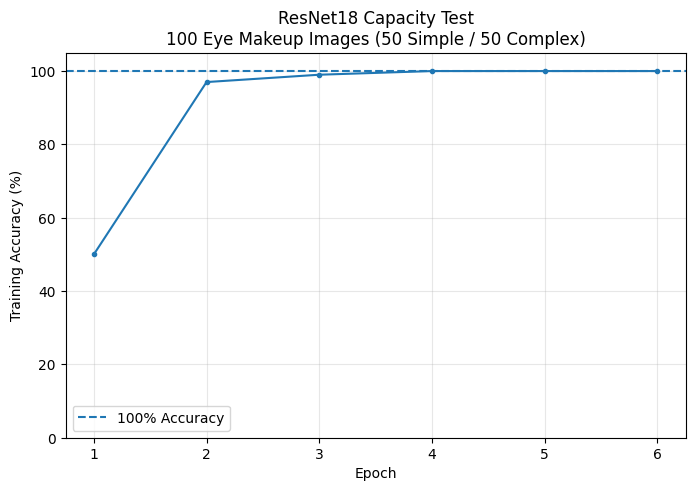

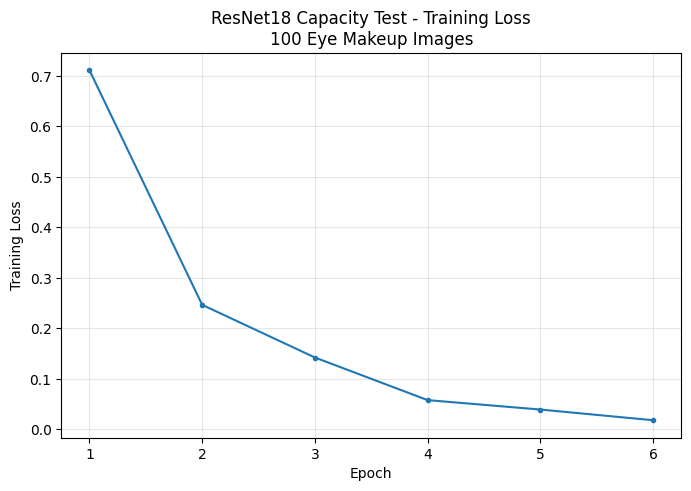


Prediction results saved to:
/content/drive/MyDrive/eye_100image_overfit_predictions.csv

Number of misclassified training images: 0

No misclassified images.
All 100 training images were classified correctly.


In [1]:
# ============================================================
# ResNet18 Capacity Test
# 100 Eye Makeup Images:
#   50 Simple, 50 Complex
# No Data Augmentation
# Goal: Test whether ResNet18 can reach 100% training accuracy
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# 3. RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 4. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# 5. PATHS AND SETTINGS
# ============================================================

IMG_DIR = '/content/drive/MyDrive/makeup/eye'

CSV_PATH = '/content/complexity_labels_region_binary.csv'

SAVE_PATH = (
    '/content/drive/MyDrive/'
    'resnet18_eye_100image_overfit.pth'
)

# Maximum number of epochs
EPOCHS = 100

LR = 1e-4

BATCH_SIZE = 16


# ============================================================
# 6. LABEL MAP
# ============================================================

# Binary classification: simple  = 0,complex = 1
LABEL_MAP = {
    'simple': 0.0,
    'complex': 1.0
}


# ============================================================
# 7. TRANSFORM
# ============================================================

# IMPORTANT:
# NO DATA AUGMENTATION for this experiment; Only resize + normalization

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 8. DATASET CLASS
# ============================================================

class MakeupDataSet(Dataset):

    def __init__(self, df, img_dir, transform):

        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = os.path.join(
            self.img_dir,
            row['filename']
        )

        image = Image.open(
            image_path
        ).convert('RGB')

        image = self.transform(image)

        label = torch.tensor(
            LABEL_MAP[row['eye_label']],
            dtype=torch.float32
        )

        return image, label


# ============================================================
# 9. LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\nOriginal CSV size:")
print(len(df))

print("\nOriginal eye label distribution:")
print(df['eye_label'].value_counts())


# ============================================================
# 10. KEEP ONLY SIMPLE AND COMPLEX
# ============================================================
# Remove any other class if it exists.

df = df[
    df['eye_label'].isin(
        ['simple', 'complex']
    )
].copy()

# If the CSV contains non-makeup images with
# eye_count = 0, remove them here.

if 'eye_count' in df.columns:

    print(
        "\nRemoving images with eye_count = 0 "
        "(non-makeup images)..."
    )

    df = df[
        df['eye_count'] > 0
    ].copy()


# ============================================================
# 12. CHECK WHETHER EYE IMAGES EXIST
# ============================================================

df["image_path"] = df["filename"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

missing = df[
    ~df["image_path"].apply(os.path.exists)
]

print("\nMissing eye images:")
print(len(missing))

if len(missing) > 0:
    print(missing["filename"].tolist())


# Keep only images that actually exist
df = df[
    df["image_path"].apply(os.path.exists)
].copy().reset_index(drop=True)


print("\nAvailable makeup eye images:")
print(df['eye_label'].value_counts())


# ============================================================
# 13. MAKE SURE WE HAVE AT LEAST 50 PER CLASS
# ============================================================

num_simple = (
    df['eye_label'] == 'simple'
).sum()

num_complex = (
    df['eye_label'] == 'complex'
).sum()

print("\nAvailable simple:", num_simple)
print("Available complex:", num_complex)

assert num_simple >= 50, (
    "Not enough simple images. "
    f"Only {num_simple} available."
)

assert num_complex >= 50, (
    "Not enough complex images. "
    f"Only {num_complex} available."
)


# ============================================================
# 14. RANDOMLY SAMPLE 50 SIMPLE
# ============================================================

simple_df = df[
    df['eye_label'] == 'simple'
].sample(
    n=50,
    random_state=SEED
)


# ============================================================
# 15. RANDOMLY SAMPLE 50 COMPLEX
# ============================================================

complex_df = df[
    df['eye_label'] == 'complex'
].sample(
    n=50,
    random_state=SEED
)


# ============================================================
# 16. COMBINE INTO 100-IMAGE DATASET
# ============================================================

small_df = pd.concat(
    [
        simple_df,
        complex_df
    ],
    ignore_index=True
)


# Shuffle the 100 images
small_df = small_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)


print("\n======================================")
print("100-IMAGE EXPERIMENT DATASET")
print("======================================")

print(
    small_df['eye_label'].value_counts()
)

print(
    "\nTotal number of images:",
    len(small_df)
)

# ============================================================
# 18. SAVE THE SELECTED 100 IMAGES TO CSV
# ============================================================
# Useful because this records exactly which 100 images
# were used in this experiment.

SUBSET_CSV_PATH = (
    '/content/drive/MyDrive/'
    'eye_100image_subset.csv'
)

small_df[
    ['filename', 'eye_label']
].to_csv(
    SUBSET_CSV_PATH,
    index=False
)

print(
    "\n100-image subset saved to:"
)

print(SUBSET_CSV_PATH)


# ============================================================
# 19. CREATE TRAINING DATASET
# ============================================================

# All 100 images are used for training because the goal is to test whether ResNet18 can MEMORIZE the small dataset.

train_df = small_df.copy()

train_dataset = MakeupDataSet(
    train_df,
    IMG_DIR,
    train_tf
)


# ============================================================
# 20. CREATE TRAINING DATALOADER
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print(
    "\nTraining images:",
    len(train_dataset)
)


# ============================================================
# 21. CREATE RESNET18
# ============================================================

model = models.resnet18(
    weights='IMAGENET1K_V1'
)


# ============================================================
# 22. REPLACE FINAL CLASSIFICATION LAYER
# ============================================================

# Binary classification:
# one output logit
#
# BCEWithLogitsLoss will apply sigmoid internally.

model.fc = nn.Linear(
    model.fc.in_features,
    1
)


# ============================================================
# 23. TRAIN THE ENTIRE RESNET18
# ============================================================

# DO NOT freeze the network for this experiment.
#
# We WANT the network to overfit / memorize these 100 images.

for param in model.parameters():

    param.requires_grad = True


model = model.to(device)


# ============================================================
# 24. LOSS FUNCTION
# ============================================================

criterion = nn.BCEWithLogitsLoss()


# ============================================================
# 25. OPTIMIZER
# ============================================================

# No weight decay.
# we are NOT trying to prevent overfitting.
# We are intentionally testing model capacity.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# 26. PRINT MODEL INFORMATION
# ============================================================

print("\nFinal classification layer:")

print(model.fc)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    "\nTrainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)


# ============================================================
# 27. STORAGE FOR TRAINING CURVES
# ============================================================

train_losses = []
train_accuracies = []

# Used for early stopping after 100% accuracy
consecutive_100 = 0


# ============================================================
# 28. TRAINING LOOP
# ============================================================

print("\n======================================")
print("START TRAINING")
print("======================================\n")


for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    train_correct = 0
    train_total = 0


    # --------------------------------------------------------
    # TRAIN ONE EPOCH
    # --------------------------------------------------------

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(
            device
        ).unsqueeze(1)


        # Clear previous gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation
        loss.backward()


        # Update model weights
        optimizer.step()


        # ----------------------------------------------------
        # ACCUMULATE LOSS
        # ----------------------------------------------------

        running_loss += (
            loss.item()
            * images.size(0)
        )


        # ----------------------------------------------------
        # PREDICTIONS
        # ----------------------------------------------------

        probabilities = torch.sigmoid(
            outputs
        )

        preds = (
            probabilities >= 0.5
        ).float()


        train_correct += (
            preds == labels
        ).sum().item()

        train_total += (
            labels.size(0)
        )


    # ========================================================
    # EPOCH STATISTICS
    # ========================================================

    train_loss = (
        running_loss
        / train_total
    )

    train_acc = (
        train_correct
        / train_total
    )


    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_acc
    )


    print(
        f"Epoch "
        f"{epoch + 1:03d}/{EPOCHS} | "
        f"Loss: {train_loss:.6f} | "
        f"Training Accuracy: "
        f"{train_acc * 100:.2f}%"
    )


    # ========================================================
    # CHECK IF TRAINING ACCURACY REACHES 100%
    # ========================================================

    if train_acc == 1.0:

        consecutive_100 += 1

    else:

        consecutive_100 = 0


    # Require 3 consecutive epochs at 100%
    # so that one lucky epoch does not trigger stopping.

    if consecutive_100 >= 3:

        print(
            "\n======================================"
        )

        print(
            "Reached 100% training accuracy "
            "for 3 consecutive epochs."
        )

        print(
            "ResNet18 successfully memorized "
            "the 100-image dataset."
        )

        print(
            "======================================"
        )

        break


# ============================================================
# 29. SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    SAVE_PATH
)

print(
    "\nModel saved to:"
)

print(SAVE_PATH)


# ============================================================
# 30. FINAL TRAINING-SET EVALUATION
# ============================================================

# IMPORTANT:
#
# Now evaluate the SAME 100 images again using model.eval().
#
# This gives us the final training-set accuracy after training.

model.eval()

final_correct = 0
final_total = 0

all_predictions = []
all_labels = []
all_probabilities = []


with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(
            device
        ).unsqueeze(1)


        outputs = model(images)


        probabilities = torch.sigmoid(
            outputs
        )


        preds = (
            probabilities >= 0.5
        ).float()


        final_correct += (
            preds == labels
        ).sum().item()

        final_total += (
            labels.size(0)
        )


        all_predictions.extend(
            preds.squeeze(1)
            .cpu()
            .numpy()
        )


        all_labels.extend(
            labels.squeeze(1)
            .cpu()
            .numpy()
        )


        all_probabilities.extend(
            probabilities.squeeze(1)
            .cpu()
            .numpy()
        )


# ============================================================
# 31. FINAL TRAINING ACCURACY
# ============================================================

final_train_acc = (
    final_correct
    / final_total
)


print(
    "\n======================================"
)

print(
    "FINAL RESULT"
)

print(
    "======================================"
)

print(
    f"Final Training Accuracy: "
    f"{final_train_acc * 100:.2f}%"
)

print(
    f"Correct predictions: "
    f"{final_correct}/{final_total}"
)


# ============================================================
# 32. INTERPRET RESULT
# ============================================================

if final_train_acc == 1.0:

    print(
        "\nSUCCESS:"
    )

    print(
        "ResNet18 achieved 100% training accuracy."
    )

    print(
        "This indicates that ResNet18 has enough "
        "capacity to memorize this 100-image dataset."
    )

else:

    print(
        "\nResNet18 did NOT reach 100% "
        "final training accuracy."
    )

    print(
        "Further investigation may be needed."
    )


# ============================================================
# 33. PLOT TRAINING ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(train_accuracies) + 1
    ),
    np.array(
        train_accuracies
    ) * 100,
    marker='o',
    markersize=3
)

plt.axhline(
    y=100,
    linestyle='--',
    label='100% Accuracy'
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Accuracy (%)"
)

plt.title(
    "ResNet18 Capacity Test\n"
    "100 Eye Makeup Images "
    "(50 Simple / 50 Complex)"
)

plt.ylim(
    0,
    105
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()


# ============================================================
# 34. PLOT TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(train_losses) + 1
    ),
    train_losses,
    marker='o',
    markersize=3
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "ResNet18 Capacity Test - Training Loss\n"
    "100 Eye Makeup Images"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 35. SAVE PREDICTION RESULTS
# ============================================================

evaluation_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


model.eval()

predictions = []
probabilities_list = []


with torch.no_grad():

    for images, labels in evaluation_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(
            outputs
        )

        preds = (
            probabilities >= 0.5
        ).float()


        predictions.extend(
            preds.squeeze(1)
            .cpu()
            .numpy()
            .astype(int)
        )

        probabilities_list.extend(
            probabilities.squeeze(1)
            .cpu()
            .numpy()
        )


# Add prediction results to dataframe

result_df = train_df[
    ['filename', 'eye_label']
].copy()


result_df[
    'true_label'
] = result_df[
    'eye_label'
].map({
    'simple': 0,
    'complex': 1
})


result_df[
    'predicted_label'
] = predictions


result_df[
    'complex_probability'
] = probabilities_list


result_df[
    'correct'
] = (
    result_df['true_label']
    ==
    result_df['predicted_label']
)


# ============================================================
# 36. SAVE PREDICTIONS
# ============================================================

RESULT_CSV_PATH = (
    '/content/drive/MyDrive/'
    'eye_100image_overfit_predictions.csv'
)

result_df.to_csv(
    RESULT_CSV_PATH,
    index=False
)

print(
    "\nPrediction results saved to:"
)

print(
    RESULT_CSV_PATH
)


# ============================================================
# 37. SHOW MISCLASSIFIED IMAGES
# ============================================================

wrong_df = result_df[
    result_df['correct'] == False
]

print(
    "\nNumber of misclassified training images:",
    len(wrong_df)
)


if len(wrong_df) > 0:

    print(
        "\nMisclassified images:"
    )

    print(
        wrong_df[
            [
                'filename',
                'eye_label',
                'predicted_label',
                'complex_probability'
            ]
        ]
    )

else:

    print(
        "\nNo misclassified images."
    )

    print(
        "All 100 training images were "
        "classified correctly."
    )